<a href="https://colab.research.google.com/github/Chhatrapal12/Chhatrapal12-/blob/main/Aimlproject_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Predictions: [531971.94704325 540750.79920607 539946.27834671 538692.04184045
 547039.32554202 535171.18460451 533823.76675319 540566.86429587
 545529.24643657 539311.12571808 526399.61578142 531287.31310798
 532572.53438997 535685.52460065 543660.78161251 532112.18191503
 536515.82533065 528134.55271032 533642.2596229  535151.41301995
 544485.30107429 536038.47839632 533714.16731188 534728.97931521
 531436.33339102 534663.77860284 535823.90805565 535920.44288901
 544272.5821504  526336.4935037  535455.81121738 538063.24684317
 530700.7160776  531728.59268889 540178.4195099  535486.44664784
 533306.64963187 528350.62512251 535242.16658509 531118.29422251
 538482.3270596  533587.92275644 526222.38784783 536134.08752129
 537911.79878022 536661.49212539 534748.75089977 541786.53552022
 535436.38897808 538928.11285507 535314.07427407 542671.74947982
 543252.91458724 530614.24170915 533746.65415913 539654.01904885
 531939.80954126 536070.03953518 532090.90825895 533236.24401442
 530958.9864

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


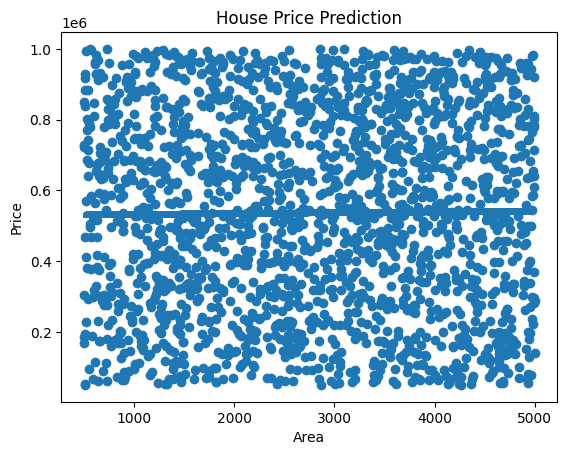

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/content/House Price Prediction Dataset.csv")

# Features (X) and Target (y)
X = data[['Area', 'Bedrooms']]
y = data['Price']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Print predictions
print("Predictions:", y_pred)

# Predict new house price
new_house = [[1000, 3]]  # Area=1000, Bedrooms=3
price = model.predict(new_house)
print("Predicted Price:", price[0])

# Visualization (only Area vs Price)
plt.scatter(data['Area'], data['Price'])
plt.plot(data['Area'], model.predict(data[['Area','Bedrooms']]), linestyle='dashed')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Price Prediction")
plt.show()

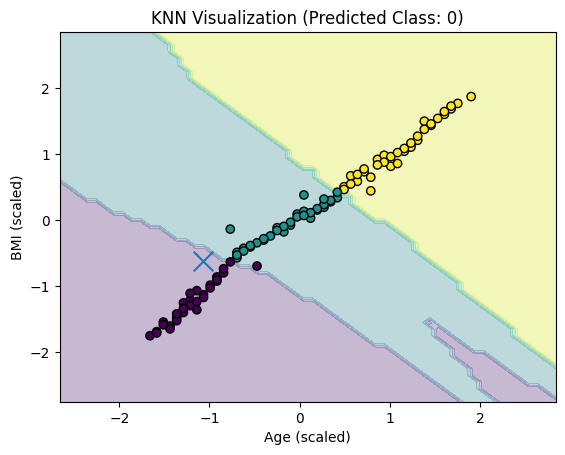

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load CSV
data = pd.read_csv("/content/knn_dataset.csv")

# Features & target
X = data[['age', 'bmi']].values # Corrected 'salary' to 'bmi'
y = data['label'].values # Corrected 'bought' to 'label'

# Scale features (IMPORTANT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

# Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict grid points
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual data points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='k')

# New test point (adjusted for 'age' and 'bmi')
new_point = np.array([[30, 25]]) # Example: age 30, bmi 25
new_point_scaled = scaler.transform(new_point)

prediction = knn.predict(new_point_scaled)

# Plot test point
plt.scatter(new_point_scaled[:, 0], new_point_scaled[:, 1],
            marker='x', s=200)

plt.title(f"KNN Visualization (Predicted Class: {prediction[0]})")
plt.xlabel("Age (scaled)")
plt.ylabel("BMI (scaled)") # Updated label
plt.show()